## import all required library 

In [1]:
from PIL import Image
import numpy as np
import os
from random import shuffle
from tqdm import tqdm
import matplotlib.pyplot as plt

# PIL =python image library ,convert image into equal size images 
# os = used to load image 
# shuffle = used to shuffle loded image 

## load data set 

In [2]:
TRAIN_DIR = "C:\\Dataset\\TRAIN"
TEST_DIR = "C:\\Dataset\\TEST"

## coverting image size to standard one size 

In [3]:
IMG_SIZE = 120
LR = 1e-3

MODEL_NAME = 'NIKEvsADIDAS--{}-{}.model'.format(LR, '2conv-basic')

## labeling images 

In [4]:
def label_img(img):
    # Images are formatted as: ADIDAS_1, NIKE_3 ...
    word_label = img.split('_')[0]
    if word_label == 'NIKE': return [1,0] #one hot encoding
    elif word_label == 'ADIDAS': return [0,1] #one hot encoding

## Loads images from the training directory, converts them to grayscale, resizes to fixed dimensions, assigns labels, converts to NumPy arrays, shuffles the dataset, and saves it as a .npy file for CNN training.

In [5]:
def create_train_data():
    train_data = []
    
    for img in tqdm(os.listdir(TRAIN_DIR)):
        label = label_img(img)
        path = os.path.join(TRAIN_DIR, img)

        img = Image.open(path)
        img = img.convert('L')
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

        train_data.append([np.array(img), np.array(label)])

    shuffle(train_data)

    np.save('train_data.npy', np.array(train_data, dtype=object))

    return train_data

## Preprocesses test images by converting to grayscale, resizing, extracting image IDs, shuffling, and saving them as a NumPy dataset for model testing.

In [6]:
def process_test_data():
    test_data = []
    for img in tqdm(os.listdir(TEST_DIR)):
        path = os.path.join(TEST_DIR, img)
        if "DS_Store" not in path:
            img_num = img.split('_')[1] #images are formatted 'NIKE_2', 'ADIDAS_56'..
        
            #PIL LIBRARY instead of cv2
            img = Image.open(path)
            img = img.convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)        
            test_data.append([np.array(img), img_num])
    shuffle(test_data)
    np.save('test_data.npy', test_data)
    return test_data
        

## cheking the output 

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 80.95it/s]


[1 0]


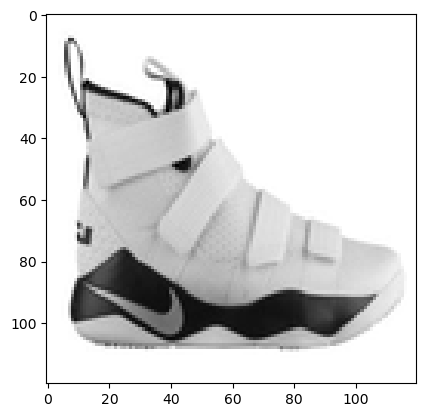

In [7]:
# train_data = create_train_data()
# plt.imshow(train_data[5][0], cmap='gist_gray')
# plt.show()
# print(train_data[43][1])

train_data = create_train_data()
plt.imshow(train_data[43][0], cmap = 'gist_gray')
print(train_data[43][1])


In [8]:
#!pip install tensorflow

## imported necessary library for model training ,tensorflow 

In [9]:
import tensorflow as tf
print(tf.__version__)

2.18.1


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten

## Builds a CNN model with multiple convolution and max-pooling layers for feature extraction, followed by flattening and dense layers to classify grayscale images into two classes (Adidas vs Nike) using softmax activation.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(120,120,1)))

model.add(Conv2D(32, (5,5), activation='relu'))
model.add(Conv2D(32, (5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (5,5), activation='relu'))
model.add(Conv2D(64, (5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (5,5), activation='relu'))
model.add(Conv2D(64, (5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 116, 116, 32)        │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 32)        │          25,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 48, 48, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 20, 20, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,483,810 (9.47 MB)

 Trainable params: 2,483,810 (9.47 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
x= np.array([i[0] for i in train_data]).reshape(-1,IMG_SIZE,IMG_SIZE,1)
y=np.array([i[1] for i in train_data])

model.fit(x,y,epochs=15)
# model.predict(x[0].reshape(-1,IMG_SIZE,IMG_SIZE,1)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5500 - loss: 30.7011
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4700 - loss: 0.8741
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4800 - loss: 0.7880
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6600 - loss: 0.6674
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6700 - loss: 0.6399
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7000 - loss: 0.6088
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6000 - loss: 0.6069
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6400 - loss: 0.6350
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7200 - loss: 0.5247
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7100 - loss: 0.5498
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6700 - loss: 0.6281
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7400 - loss: 0.5270
Epoch 13/15
4/4 ━━━━━━━

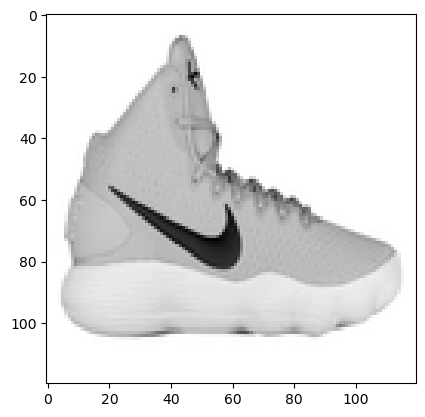

In [14]:
img = Image.open("C:\\Dataset\\TRAIN\\NIKE_14.png")
img = img.convert('L')
img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS) 
plt.imshow(np.array(img), cmap = 'gist_gray')
plt.show()

In [15]:
model.predict(np.array(img).reshape(-1,IMG_SIZE,IMG_SIZE,1))


# 'NIKE': return [1,0] 
# 'ADIDAS': return [0,1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step


array([[0.93484694, 0.06515302]], dtype=float32)

In [16]:
# Save trained CNN model for Flask deployment



In [17]:
model.save("nike_adidas_model.keras")

print("✅ Model successfully saved as nike_adidas_model.keras")

✅ Model successfully saved as nike_adidas_model.keras
